# Gate Lift Comparison
Loads multiple `*_gate_lift.csv` files, aligns them to lift-off, and plots gate displacement and speed.

In [2]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use given style
plt.style.use("james2026lock.mplstyle")

## 1. Point to your CSV files
Set `CSV_DIR` to the folder containing your `*_gate_lift.csv` files.

In [3]:
CSV_DIR = "../../data/metadata/gate_lift/"

csv_files = sorted(glob.glob(os.path.join(CSV_DIR, "gatelift*.csv")))
labels = [
    os.path.basename(f).replace("gatelift_", "").replace(".csv", "") for f in csv_files
]

print(f"Found {len(csv_files)} file(s):")
for f in csv_files:
    print(" ", os.path.basename(f))

Found 6 file(s):
  gatelift1.csv
  gatelift2.csv
  gatelift3.csv
  gatelift4.csv
  gatelift5.csv
  gatelift6.csv


## 2. Load CSVs

In [4]:
# Expected columns: Time_s, GateDisplacement_cm, LiftSpeed_cm_per_s
dfs = [pd.read_csv(f) for f in csv_files]

for label, df in zip(labels, dfs):
    print(f"  {label}: {len(df)} frames")

  gatelift1: 600 frames
  gatelift2: 661 frames
  gatelift3: 421 frames
  gatelift4: 541 frames
  gatelift5: 361 frames
  gatelift6: 601 frames


## 3. Detect lift-off and align time
Lift-off is defined as the first frame where speed exceeds 10 % of that run's peak.
Time is shifted so t = 0 is lift-off; position is zeroed at lift-off too.

In [5]:
LIFTOFF_THRESHOLD = 0.10  # fraction of peak speed

t_aligned = []
pos_aligned = []
spd_aligned = []
peak_speeds = []
total_travel = []

for df in dfs:
    t = df["Time_s"].values
    pos = df["GateDisplacement_cm"].values
    spd = df["LiftSpeed_cm_per_s"].values

    peak = spd.max()
    peak_speeds.append(peak)

    # First frame above threshold
    idx = np.argmax(spd > LIFTOFF_THRESHOLD * peak)
    if spd[idx] <= LIFTOFF_THRESHOLD * peak:
        idx = 0  # fallback if nothing found

    t_aligned.append(t - t[idx])
    pos_aligned.append(pos - pos[idx])  # zero at lift-off
    spd_aligned.append(spd)
    total_travel.append(abs(pos[-1] - pos[idx]))

peak_speeds = np.array(peak_speeds)
total_travel = np.array(total_travel)

## 4. Summary table

In [6]:
summary = pd.DataFrame(
    {
        "Experiment": labels,
        "PeakSpeed_cm_per_s": peak_speeds.round(2),
        "TotalTravel_cm": total_travel.round(2),
    }
)

# Append mean / std / CV rows
summary.loc["Mean"] = [
    "Mean",
    peak_speeds.mean().round(2),
    total_travel.mean().round(2),
]
summary.loc["Std"] = ["Std", peak_speeds.std().round(2), total_travel.std().round(2)]
summary.loc["CV%"] = [
    "CV %",
    f"{100*peak_speeds.std()/peak_speeds.mean():.1f} %",
    f"{100*total_travel.std()/total_travel.mean():.1f} %",
]

display(summary)

# Save
out_path = os.path.join(CSV_DIR, "gate_lift_summary.csv")
summary.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

,Experiment,PeakSpeed_cm_per_s,TotalTravel_cm
0,gatelift1,5.18,15.07
1,gatelift2,5.3,15.07
2,gatelift3,5.14,15.74
3,gatelift4,5.21,14.98
4,gatelift5,5.22,15.55
5,gatelift6,5.01,15.75
Mean,Mean,5.18,15.36
Std,Std,0.09,0.33
CV%,CV %,1.7 %,2.1 %


Saved to ../../data/metadata/gate_lift/gate_lift_summary.csv


## 5. Plot — gate displacement and speed

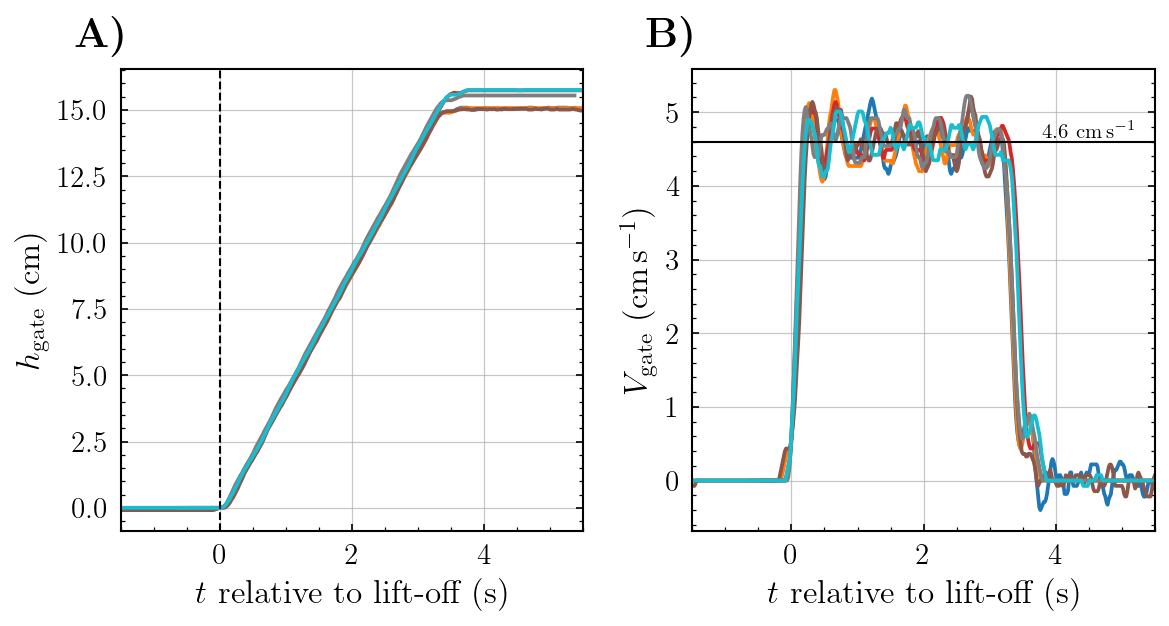

In [9]:
colours = plt.cm.tab10(np.linspace(0, 0.9, len(csv_files)))

fig, (ax_pos, ax_spd) = plt.subplots(1, 2, figsize=(8, 4), sharex=False)
fig.subplots_adjust(hspace=0.4)

# ── Top panel: gate displacement ──────────────────────────────────────────

for t, pos, label, c in zip(t_aligned, pos_aligned, labels, colours):
    ax_pos.plot(t, pos, color=c, linewidth=1.8, label=label)

ax_pos.axvline(0, color="black", linestyle="--", linewidth=1.0, label="lift-off")
ax_pos.set_xlabel("$t$ relative to lift-off (s)")
ax_pos.set_ylabel("$h_{\\mathrm{gate}}$ (cm)")

# ── Bottom panel: lift speed ───────────────────────────────────────────────
for t, spd, label, c in zip(t_aligned, spd_aligned, labels, colours):
    ax_spd.plot(t, spd, color=c, linewidth=1.8, label=label)

# ax_spd.axvline(0, color="black", linestyle="--", linewidth=1.0, label="lift-off")
ax_spd.axhline(4.6, color="black", linestyle="-", linewidth=1.0, label="lift-off")
ax_spd.set_xlabel("$t$ relative to lift-off (s)")
ax_spd.set_ylabel("$V_{\\mathrm{gate}}$ (cm$\\,$s$^{-1}$)")

ax_spd.text(3.8, 4.65, "4.6 cm$\\,$s$^{-1}$", fontsize=10)


ax_pos.set_xlim([-1.5, 5.5])
ax_spd.set_xlim([-1.5, 5.5])

for axis, label in zip([ax_pos, ax_spd], ["\\textbf{A)}", "\\textbf{B)}"]):
    axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
    )

plt.tight_layout()
plt.savefig("../figures/figure_S1.png", dpi=300, bbox_inches="tight")
plt.show()